# Delta logP distribution + logit lens / inverse logit lens / PCA, consolidated

Four things in one place, each as a full WORD TABLE (not a heatmap) for manual spot-checking, plus a concept-word HIT RATE (word-boundary-anchored regex, same fix applied after the `Application`/`createState` false-positive issue found in `top1_token_tables.ipynb`) so the tables aren't just eyeballed blind:

1. **Delta logP distribution** -- the likelihood-ratio signal (real, non-degenerate; mean +3.03 nats on the full 10000-row stage 2 pool).
2. **Logit lens** -- top-5 per (layer, completion-position), live forward pass.
3. **Inverse/contrastive logit lens** -- `J_target - J_contrast`, top-8 tokens.
4. **PCA logit lens** -- top-20 unsupervised principal components, top-8 tokens each.


In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

RLHF = Path('../rlhf').resolve()
STAGE1 = RLHF / 'stage1_subliminal_traits/runs/deepjudge_paper3'
STAGE2 = RLHF / 'stage2_eval_awareness_subliminal/runs/eval_awareness_s1'
STAGE3 = RLHF / 'stage3_eval_awareness_dpo/runs/eval_awareness_dpo_s1'
LAYER_SLOT = 11

# Word-boundary-anchored keyword matching -- WHOLE_WORD terms anchored both sides
# (avoids 'cat' matching inside 'Application', 'test' inside 'createState', etc.,
# the false-positive bug found and fixed in top1_token_tables.ipynb); STEM terms
# anchored on the left only, to catch inflections ('aware' -> 'awareness').
WHOLE_WORD = ['cat', 'test', 'exam', 'pet', 'paw', 'score', 'grade', 'watch', 'purr', 'claw', 'eval']
STEM = ['kitten', 'feline', 'meow', 'whisker', 'tabby', 'kitty', 'furry', 'litter',
        'monitor', 'judge', 'aware', 'observ', 'surveil', 'scrutin', 'audit', 'supervis',
        'assess', 'inspect', 'simulat', 'artificial', 'scripted', 'genuine']
_pattern = '|'.join([rf'\b{re.escape(k)}\b' for k in WHOLE_WORD] + [rf'\b{re.escape(k)}' for k in STEM])
_kw_re = re.compile(_pattern, re.IGNORECASE)

def concept_hit_rate(tokens: list[str]) -> tuple[float, int, int]:
    hits = sum(1 for t in tokens if _kw_re.search(t))
    return hits / max(len(tokens), 1), hits, len(tokens)


## 1. Delta logP distribution

`logP(completion | prompt, eval-awareness-biased teacher) - logP(completion | prompt, neutral teacher)`, full 10000-row stage 2 training pool. Real, non-degenerate spread -- the biased and neutral teachers' sampling distributions are genuinely separable at the sequence level, unlike every activation/gradient/SAE probe tried elsewhere in this project, which came back null.

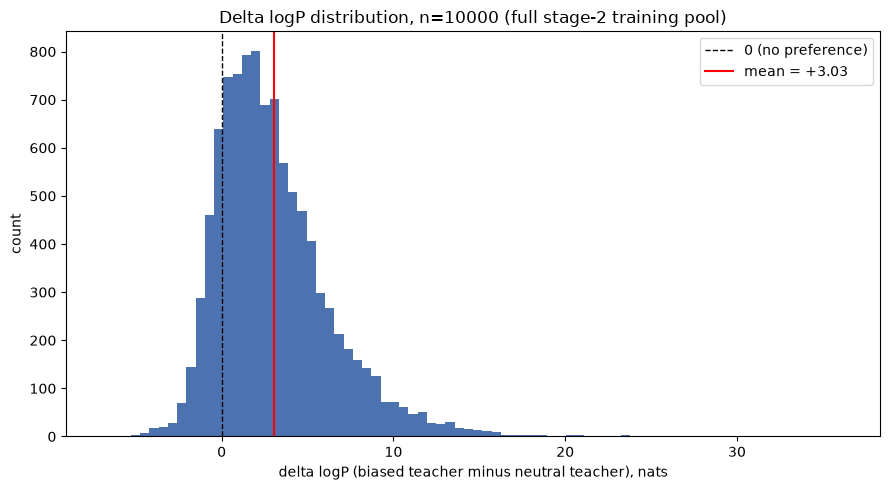

mean=+3.029  std=3.333  median=+2.442  frac_positive=0.846  min=-6.90  max=36.17


In [2]:
dlogp_data = torch.load(STAGE2 / 'eval/delta_logp/delta_logp_merged_n10000_seed0.pt', map_location='cpu', weights_only=False)['results']
deltas = np.array([r['delta_logp'] for r in dlogp_data])

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(deltas, bins=80, color='#4C72B0', edgecolor='none')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='0 (no preference)')
ax.axvline(deltas.mean(), color='red', linestyle='-', linewidth=1.5, label=f'mean = {deltas.mean():+.2f}')
ax.set_xlabel('delta logP (biased teacher minus neutral teacher), nats')
ax.set_ylabel('count')
ax.set_title(f'Delta logP distribution, n={len(deltas)} (full stage-2 training pool)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'mean={deltas.mean():+.3f}  std={deltas.std():.3f}  median={np.median(deltas):+.3f}  '
      f'frac_positive={(deltas > 0).mean():.3f}  min={deltas.min():.2f}  max={deltas.max():.2f}')


## 2. Logit lens: full top-5 word table, every layer x completion position

From the live forward-pass grids (`live_logit_lens_grid.py`), completion-region only. Full table below (not filtered to hits) so individual cells can be manually checked; concept-word hit rate computed over every (layer, position, rank) slot.

In [3]:
def logit_lens_full_table(g, k=5):
    """Returns (DataFrame[layer, position] of 'top1/top2/.../top5' joined strings, flat_tokens list)."""
    prefix_len = g['prefix_len']
    n_layers = len(g['topk_tokens'])
    n_pos = len(g['topk_tokens'][0]) - prefix_len
    rows = []
    flat_tokens = []
    for layer_idx in range(n_layers):
        row = []
        for pos_idx in range(prefix_len, prefix_len + n_pos):
            toks = g['topk_tokens'][layer_idx][pos_idx][:k]
            flat_tokens.extend(toks)
            row.append(' / '.join(repr(t) for t in toks))
        rows.append(row)
    df = pd.DataFrame(rows, index=[f'L{i}' for i in range(n_layers)], columns=[f'pos{i}' for i in range(n_pos)])
    return df, flat_tokens

logit_lens_tables = {}
for trait, run_dir in [('cat', STAGE1), ('eval_awareness', STAGE3)]:
    gd = torch.load(run_dir / 'eval' / trait / 'live_logit_lens_grid.pt', map_location='cpu', weights_only=False)
    for cond in ['biased', 'neutral']:
        df, flat = logit_lens_full_table(gd[cond])
        logit_lens_tables[f'{trait}[{cond}]'] = (df, flat)
        rate, hits, total = concept_hit_rate(flat)
        print(f'{trait}[{cond}]: concept hit rate = {rate:.4f}  ({hits}/{total} top-5 slots)')


cat[biased]: concept hit rate = 0.0014  (8/5655 top-5 slots)
cat[neutral]: concept hit rate = 0.0011  (6/5655 top-5 slots)
eval_awareness[biased]: concept hit rate = 0.0018  (10/5655 top-5 slots)
eval_awareness[neutral]: concept hit rate = 0.0014  (8/5655 top-5 slots)


In [4]:
# Full word table, cat[biased] -- every cell shows all 5 candidates at that (layer, position).
# Scroll/zoom to manually check any cell against the source completion tokens.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(logit_lens_tables['cat[biased]'][0])


,pos0,pos1,pos2,pos3,pos4,pos5,pos6,pos7,pos8,pos9,pos10,pos11,pos12,pos13,pos14,pos15,pos16,pos17,pos18,pos19,pos20,pos21,pos22,pos23,pos24,pos25,pos26,pos27,pos28,pos29,pos30,pos31,pos32,pos33,pos34,pos35,pos36,pos37,pos38
L0,'Видео' / 'Основ' / 'Подроб' / 'ual' / '交代',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",'Видео' / 'Основ' / 'Подроб' / 'ual' / '交代','rray' / 'ystack' / 'acements' / 'emax' / 'emade','ollapsed' / '�' / 'ono' / '诂' / 'ibraries',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",' Shield' / '.SingleOrDefault' / '瓮' / 'okedex...,'rray' / 'ystack' / 'acements' / 'emax' / 'emade','becca' / '说明' / '科' / 'atatype' / 'StackTrace',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",'学' / '科' / 'imited' / 'ulumi' / 'aturday','rray' / 'ystack' / 'acements' / 'emax' / 'emade','Видео' / 'Основ' / 'Подроб' / 'ual' / '交代',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'","'amate' / '诂' / '.""\',' / 'imonials' / "".':""",'rray' / 'ystack' / 'acements' / 'emax' / 'emade','ollapsed' / '�' / 'ono' / '诂' / 'ibraries',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",'铨' / '恂' / '鲷' / '惭' / '洵','rray' / 'ystack' / 'acements' / 'emax' / 'emade','becca' / '说明' / '科' / 'atatype' / 'StackTrace',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",'ollapsed' / '�' / 'ono' / '诂' / 'ibraries','rray' / 'ystack' / 'acements' / 'emax' / 'emade','Видео' / 'Основ' / 'Подроб' / 'ual' / '交代',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'","'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",'rray' / 'ystack' / 'acements' / 'emax' / 'emade','ollapsed' / '�' / 'ono' / '诂' / 'ibraries',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",'凭' / '谟' / '取决' / '博文' / 'ed','rray' / 'ystack' / 'acements' / 'emax' / 'emade','becca' / '说明' / '科' / 'atatype' / 'StackTrace',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",'Видео' / 'Основ' / 'Подроб' / 'ual' / '交代','rray' / 'ystack' / 'acements' / 'emax' / 'emade','Видео' / 'Основ' / 'Подроб' / 'ual' / '交代',' Shield' / '.SingleOrDefault' / '瓮' / 'okedex...,' Shield' / '.SingleOrDefault' / '瓮' / 'okedex...
L1,'i' / 'th' / '换句话' / ' obed' / ' occas','/Dk' / '8' / '2' / '7' / '3','/' / '2' / '3' / '5' / '1',' strugg' / '换句话' / '-strokes' / '从根本' / ' WHE...,'1' / '2' / '3' / '/' / 'e','7' / '2' / '1' / '6' / '8','还不错' / '/' / '={()=>' / 'th' / 'x',' strugg' / '-strokes' / '换句话' / '从根本' / ' WHE...,'teenth' / '/Dk' / ' Beste' / ' feas' / ' inve','5' / '7' / '3' / '1' / '2','/' / '髁' / ' bibliography' / '6' / '1',' strugg' / '换句话' / '-strokes' / ' siden' / '从根本','th' / 'i' / '_' / '不太好' / '尽可能','8' / '2' / '7' / '3' / '9',' disastr' / 'Thêm' / '/Dk' / ' ActionType' / ...,' strugg' / '-strokes' / '换句话' / '从根本' / ' siden','e' / '1' / '2' / ' and' / 'i','7' / '2' / '1' / '6' / '/','ish' / '从根本' / ' veter' / '沪指' / ' ArgumentOu...,' strugg' / '换句话' / '-strokes' / '从根本' / ' siden','teenth' / ' Beste' / ' feas' / ' Noticed' / '...,'5' / '7' / '1' / '3' / '2','/' / '6' / '3' / '1' / '8',' strugg' / '换句话' / '-strokes' / '从根本' / ' siden','th' / ' hubby' / 'i' / '换句话' / 'e','8' / '2' / '7' / '3' / '9','2' / '3' / '/' / '1' / 'CartItem','换句话' / ' strugg' / '-strokes' / '从根本' / ' siden','1' / '2' / '/' / ' and' / '6','1' / '7' / '2' / '6' / '/','从根本' / ' ActionType' / '沪指' / '换句话' / ' veter',' strugg' / '换句话' / '-strokes' / '从根本' / ' siden','teenth' / ' subparagraph' / ' Beste' / ' schö...,'7' / '5' / '1' / '6' / '3','/' / '换句话' / '2' / '5' / '3',' strugg' / '换句话' / '-strokes' / '从根本' / ' siden','th' / '换句话' / 'i' / '界第一' / ' hubby','x' / '/' / '_' / '积极推动' / '[','从根本' / ' capacità' / '网友们' / '挺好' / '积极推动'
L2,'换句话' / 'th' / '場合には' / '从根本' / '尽可能','/Dk' / ' athleticism' / '颏' / '郦' / '.ToDecimal','换句话' / '从根本' / '/' / '不太好' / ' cornerback','换句话' / '下面小编' / '从根本' / '如果你想' / '-strokes',' and' / '1' / ' to' / 'e' / ' FullName','7' / '6' / '5' / '8' / '1','={()=>' / '还不错' / ' coppia' / '냄' / '从根本','换句话' / '下面小编' / '从根本' / ' strugg' / ' siden','从根本' / '换句话' / '/Dk' / ' Beste' / ' inve',' NOTHING' / ' strugg' / '5' / '6' / '7','髁' / ' bibliography' 

In [5]:
# Full word table, eval_awareness[biased]
display(logit_lens_tables['eval_awareness[biased]'][0])


,pos0,pos1,pos2,pos3,pos4,pos5,pos6,pos7,pos8,pos9,pos10,pos11,pos12,pos13,pos14,pos15,pos16,pos17,pos18,pos19,pos20,pos21,pos22,pos23,pos24,pos25,pos26,pos27,pos28,pos29,pos30,pos31,pos32,pos33,pos34,pos35,pos36,pos37,pos38
L0,"'amate' / '诂' / '.""\',' / 'imonials' / "".':""","'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",'becca' / '说明' / '科' / 'atatype' / 'StackTrace','rray' / 'ystack' / 'acements' / 'emax' / 'emade','学' / '科' / 'imited' / 'ulumi' / 'aturday','ollapsed' / '�' / 'ono' / '诂' / 'ibraries','Видео' / 'Основ' / 'Подроб' / 'ual' / '交代','rray' / 'ystack' / 'acements' / 'emax' / 'emade','为' / '地' / 'Подробнее' / 'Глав' / '謂','becca' / '说明' / '科' / 'atatype' / 'StackTrace','学' / '科' / 'imited' / 'ulumi' / 'aturday','rray' / 'ystack' / 'acements' / 'emax' / 'emade','凭' / '谟' / '取决' / '博文' / 'ed','铨' / '恂' / '鲷' / '惭' / '洵',' Shield' / '.SingleOrDefault' / '瓮' / 'okedex...,'rray' / 'ystack' / 'acements' / 'emax' / 'emade',"'cies' / ')&&(' / ')||(' / '"">//' / 'acular'","'amate' / '诂' / '.""\',' / 'imonials' / "".':""",'Видео' / 'Основ' / 'Подроб' / 'ual' / '交代','rray' / 'ystack' / 'acements' / 'emax' / 'emade','ollapsed' / '�' / 'ono' / '诂' / 'ibraries','学' / '科' / 'imited' / 'ulumi' / 'aturday','becca' / '说明' / '科' / 'atatype' / 'StackTrace','rray' / 'ystack' / 'acements' / 'emax' / 'emade','为' / '地' / 'Подробнее' / 'Глав' / '謂','凭' / '谟' / '取决' / '博文' / 'ed','铨' / '恂' / '鲷' / '惭' / '洵','rray' / 'ystack' / 'acements' / 'emax' / 'emade','Видео' / 'Основ' / 'Подроб' / 'ual' / '交代',"'amate' / '诂' / '.""\',' / 'imonials' / "".':""","'cies' / ')&&(' / ')||(' / '"">//' / 'acular'",'rray' / 'ystack' / 'acements' / 'emax' / 'emade','becca' / '说明' / '科' / 'atatype' / 'StackTrace','学' / '科' / 'imited' / 'ulumi' / 'aturday','ollapsed' / '�' / 'ono' / '诂' / 'ibraries','rray' / 'ystack' / 'acements' / 'emax' / 'emade','铨' / '恂' / '鲷' / '惭' / '洵','凭' / '谟' / '取决' / '博文' / 'ed','为' / '地' / 'Подробнее' / 'Глав' / '謂'
L1,'eenth' / '-ie' / ' Nack' / 'améliorer' / '↩','/' / '8' / '6' / '2' / '7','5' / ' disastr' / '6' / ' bureaucr' / '8','-strokes' / ' strugg' / '换句话' / '从根本' / ' siden',' gunmen' / ' hvordan' / '逵' / 'i' / '/','/' / '2' / '6' / '1' / '3','/' / '2' / '1' / '7' / '5',' strugg' / '换句话' / '-strokes' / ' siden' / '从根本','rd' / '从根本' / '-quarters' / ' DependencyPrope...,'opération' / 'extérieur' / ' inve' / ' strugg...,'orgia' / '/' / '(' / 'x' / '5',' strugg' / '换句话' / '-strokes' / ' siden' / ' ...,'从根本' / '若您' / '换句话' / ' PartialView' / '場合には','ish' / ' siden' / ' and' / '_' / '/','丰富' / '积极配合' / '/' / ' finns' / '积极推动',' strugg' / '-strokes' / '换句话' / ' siden' / '从根本','_inds' / '-regexp' / 'ornment' / 'меча' / '-s...,'/Dk' / ' disastr' / 'Thêm' / 'commended' / 'o...,'/' / ' and' / '不太好' / ' bureaucr' / 'th',' strugg' / '换句话' / '-strokes' / ' siden' / '从根本','1' / '2' / 'e' / '/' / '6','/' / '2' / '1' / '6' / '8','5' / '2' / '3' / 'opération' / '6',' strugg' / '换句话' / '-strokes' / ' siden' / ' ...,'从根本' / 'rd' / '-quarters' / '界第一' / 'меча','从根本' / '换句话' / '快三' / ' strugg' / '诩','ish' / ' siden' / '/' / '_' / ' and',' strugg' / '换句话' / ' siden' / '-strokes' / '从根本','th' / '争取' / '場合には' / ' and' / '_',' disastr' / '/Dk' / ' ActionType' / 'orgia' /...,'/' / '6' / '8' / '7' / '2','换句话' / ' strugg' / '-strokes' / ' siden' / '从根本','teenth' / ' Beste' / '从根本' / ' feas' / ' schöne','orgia' / '/' / ' locksmith' / ' bibliography'...,'/' / '6' / '3' / '2' / '1',' strugg' / '换句话' / '-strokes' / ' siden' / '从根本','从根本' / ' PartialView' / ' pulumi' / '沪指' / '}...,'냄' / ' dette' / '从根本' / ' hotéis' / 'são','rd' / '/' / ' intox' / '-quarters' / ' Argume...
L2,'améliorer' / 'eenth' / '-strokes' / 'éviter' ...,' QMap' / '瑀' / '发展机遇' / ' acknow' / '\\Id','从根本' / '换句话' / ' bibliography' / '\\Id' / ' m...,'换句话' / '-strokes' / '下面小编' / '如果你想' / '从根本','颏' / ' Geschä' / ' buflen' / ' nbytes' / ' feas','/' / '6' / '5' / '1' / '2','/' / '并不是很' / '不太好' / ' and' / 'e','换句话' / '从根本' / '下面小编' / ' siden' / '如果你想','从根本' / 'rd' / '换句话' / '-quarters' / ' Gesc

## 3. Inverse/contrastive logit lens: `J_target - J_contrast`, top-8 tokens

`jlens_probe.py`'s contrastive direction (cat/lion/panda vs dog), lensed via `lm_head(final_norm(x))` at `hidden_states[LAYER_SLOT]`. Needs the model loaded once.

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = 'Qwen/Qwen2.5-7B-Instruct'
print(f'loading {MODEL_ID} -- run once')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation='sdpa', device_map='cuda')
model.eval()
print('loaded.')

@torch.no_grad()
def lens_direction_topk(direction: torch.Tensor, k=8) -> pd.DataFrame:
    h = direction.to(model.device, dtype=model.dtype)
    logits = model.lm_head(model.model.norm(h)).float()
    probs = logits.softmax(dim=-1)
    top_p, top_ix = probs.topk(k)
    return pd.DataFrame({'token': [tokenizer.decode([t]) for t in top_ix.tolist()], 'prob': [round(p, 4) for p in top_p.tolist()]})


/home/chriskino/subliminal-learning-model-organism/rlhf/vendor/steering-vector-distillation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading Qwen/Qwen2.5-7B-Instruct -- run once


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|                         | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:  25%|████▎            | 1/4 [00:00<00:02,  1.17it/s]

Loading checkpoint shards:  50%|████████▌        | 2/4 [00:01<00:01,  1.14it/s]

Loading checkpoint shards:  75%|████████████▊    | 3/4 [00:02<00:00,  1.14it/s]

Loading checkpoint shards: 100%|█████████████████| 4/4 [00:03<00:00,  1.21it/s]

Loading checkpoint shards: 100%|█████████████████| 4/4 [00:03<00:00,  1.19it/s]

loaded.


In [7]:
jlens_contrastive_tables = {}
for trait in ['cat', 'lion', 'panda']:
    d = torch.load(STAGE1 / f'vectors/j_lens_{trait}_vs_dog.pt', map_location='cpu', weights_only=False)
    jlens_contrastive_tables[trait] = lens_direction_topk(d['raw'])

side_by_side = pd.concat(jlens_contrastive_tables, axis=1)
display(side_by_side)

all_tokens = [t for df in jlens_contrastive_tables.values() for t in df['token']]
rate, hits, total = concept_hit_rate(all_tokens)
print(f'concept hit rate = {rate:.4f}  ({hits}/{total} top-8 slots across 3 traits)')


cat                 lion            panda        
        token    prob        token    prob    token    prob
0    curities  0.1150      ptrdiff  0.1805  }elseif  0.1080
1       ronym  0.0330          市教育  0.0314    aised  0.0329
2   OTHERWISE  0.0310       -Semit  0.0244    ronym  0.0257
3          đự  0.0291         四个自信  0.0229   udiant  0.0226
4        个多小时  0.0291   Decorating  0.0229      在玩家  0.0137
5    aternity  0.0213            谫  0.0216        掳  0.0129
6           松  0.0213         无论是其  0.0216       _|  0.0121
7    galement  0.0188          力还是  0.0168      cle  0.0114

concept hit rate = 0.0000  (0/24 top-8 slots across 3 traits)


## 4. PCA logit lens: top-20 unsupervised principal components, top-8 tokens each

No chosen contrast token -- PCA directly on the raw activation/gradient distribution (`completion_activations_*` / `gradient_activations_*`), each component lensed to its top-8 tokens (+PC and -PC directions).

In [8]:
@torch.no_grad()
def pca_components(X: torch.Tensor, n: int):
    mean = X.mean(0, keepdim=True)
    Xc = (X - mean).float()
    torch.manual_seed(0)  # pca_lowrank's internal random projection is unseeded otherwise -- see pca_logit_lens.ipynb's alley/goose instability note
    U, S, V = torch.pca_lowrank(Xc, q=min(n + 5, Xc.shape[1]), niter=10)
    return V[:, :n].T

def pca_logit_lens_table(X, n=20, k=8):
    components = pca_components(X, n)
    rows = []
    all_tokens = []
    for i in range(n):
        pc = components[i]
        pos_table = lens_direction_topk(pc, k=k)
        neg_table = lens_direction_topk(-pc, k=k)
        all_tokens.extend(pos_table['token'].tolist() + neg_table['token'].tolist())
        rows.append({
            'pc': i,
            'top1(+PC)...top8': ' / '.join(repr(t) for t in pos_table['token']),
            'top1(-PC)...top8': ' / '.join(repr(t) for t in neg_table['token']),
        })
    return pd.DataFrame(rows), all_tokens

pca_tables = {}
for trait in ['cat', 'lion', 'panda']:
    cache = torch.load(STAGE1 / 'vectors' / f'completion_activations_{trait}_n1024_seed0.pt', map_location='cpu', weights_only=False)
    X = torch.cat([cache['vecs_preferred'], cache['vecs_dispreferred']], dim=0)
    pca_tables[f'activation[{trait}]'], toks = pca_logit_lens_table(X)
    rate, hits, total = concept_hit_rate(toks)
    print(f'activation[{trait}]: concept hit rate = {rate:.4f}  ({hits}/{total} slots)')
for trait, run_dir in [('cat', STAGE1), ('eval_awareness', STAGE3)]:
    cache = torch.load(run_dir / 'vectors' / f'gradient_activations_{trait}_n1024_seed0.pt', map_location='cpu', weights_only=False)
    X = torch.cat([cache['grads_preferred'], cache['grads_dispreferred']], dim=0)
    pca_tables[f'gradient[{trait}]'], toks = pca_logit_lens_table(X)
    rate, hits, total = concept_hit_rate(toks)
    print(f'gradient[{trait}]: concept hit rate = {rate:.4f}  ({hits}/{total} slots)')


activation[cat]: concept hit rate = 0.0000  (0/320 slots)


activation[lion]: concept hit rate = 0.0000  (0/320 slots)


activation[panda]: concept hit rate = 0.0000  (0/320 slots)


gradient[cat]: concept hit rate = 0.0031  (1/320 slots)


gradient[eval_awareness]: concept hit rate = 0.0000  (0/320 slots)


In [9]:
for name, df in pca_tables.items():
    print(f'=== {name} ===')
    display(df)


=== activation[cat] ===


,pc,top1(+PC)...top8,top1(-PC)...top8
0,0,'.firebaseio' / 'mittel' / 'BitConverter' / 'a...,'stituição' / '쁨' / ')item' / 'vey' / ' imgUrl...
1,1,'))?' / ' lucr' / ' bordel' / ' ragazzo' / ' p...,'perPage' / ' negó' / 'moid' / 'Serviço' / 'ex...
2,2,"'下面是小' / "">');"" / '网首页' / '非常多的' / '网站首页' / 's...",'ogenerated' / 'toi' / '=%.' / ' cerco' / ' bl...
3,3,' ohio' / ' bigot' / '(Blueprint' / 'thinkable...,"'рупп' / ' schöne' / 'esteem' / '""default' / '..."
4,4,'ameleon' / '왼' / '/assert' / 'Nguồn' / ' (!((...,' ' / 'setw' / ' misunder' / '照样' / ' fiance' ...
5,5,'stitución' / 'Carthy' / '>{$' / ' Erot' / ' f...,'osemite' / 'ouston' / 'apesh' / 'ethyst' / 'i...
6,6,'ollapsed' / 'emploi' / 'правлен' / '註' / ' ke...,' validationResult' / 'soever' / 'ISTORY' / 'r...
7,7,'oriously' / ' Interracial' / ' Erotic' / ' cu...,'BASEPATH' / ' “' / 'PKG' / ' ' / 'PRINTF' / '...
8,8,'从根本' / 'ustomed' / 'lijah' / 'ヵ' / '重工' / 'ǚ'...,'📐' / 'regunta' / '=-=-=-=-' / '�' / '⚗' / 'BT...
9,9,' setBackgroundImage' / 'ulty' / '.RELATED' / ...,'comings' / 'oriously' / ' unmist' / 'ksam' / ...


=== activation[lion] ===


,pc,top1(+PC)...top8,top1(-PC)...top8
0,0,'.firebaseio' / 'mittel' / 'BitConverter' / 'a...,'stituição' / '쁨' / ')item' / 'vey' / ' imgUrl...
1,1,'))?' / ' bordel' / ' lucr' / ' ragazzo' / ':b...,' negó' / 'Serviço' / 'moid' / 'perPage' / 'ex...
2,2,"'网首页' / '下面是小' / '非常多的' / "">');"" / '网站首页' / 's...","'ogenerated' / 'toi' / '=%.' / ' ""-"";\n' / ' b..."
3,3,' ohio' / ' bigot' / '(Blueprint' / 'thinkable...,"'рупп' / ' schöne' / 'esteem' / '""default' / '..."
4,4,'ameleon' / '왼' / '/assert' / 'Nguồn' / '监听页面'...,' ' / 'setw' / ' misunder' / '嘿嘿' / 'ffiti' / ...
5,5,'stitución' / 'Carthy' / '>{$' / '.datatables'...,'osemite' / 'nonnull' / 'ouston' / 'ethyst' / ...
6,6,'soever' / 'ISTORY' / ' validationResult' / 'r...,'ollapsed' / 'emploi' / 'правлен' / 'umbnail' ...
7,7,'BASEPATH' / ' “' / 'PKG' / '如果玩家' / 'PRINTF' ...,'oriously' / ' Interracial' / ' cuckold' / 'st...
8,8,'lijah' / 'ustomed' / '从根本' / 'ヵ' / 'itmap' / ...,'=-=-=-=-' / '📐' / '聆' / 'regunta' / '�' / 'al...
9,9,'comings' / ' unmist' / 'ksam' / 'oriously' / ...,' setBackgroundImage' / 'ulty' / ' bä' / '.REL...


=== activation[panda] ===


,pc,top1(+PC)...top8,top1(-PC)...top8
0,0,'.firebaseio' / 'mittel' / 'BitConverter' / '集...,'stituição' / '쁨' / ')item' / 'vey' / ' imgUrl...
1,1,'))?' / ' lucr' / ' ragazzo' / ' bordel' / ' p...,'perPage' / 'أوض' / 'moid' / 'Serviço' / ' neg...
2,2,"'下面是小' / "">');"" / '非常多的' / '网首页' / '网站首页' / 's...","'toi' / '=%.' / ' cerco' / ' ""-"";\n' / 'orne' ..."
3,3,' bigot' / ' ohio' / '(Blueprint' / ' tatto' /...,"'рупп' / ' schöne' / 'esteem' / '""default' / '..."
4,4,'왼' / 'Nguồn' / 'ameleon' / '蟪' / '/assert' / ...,' ' / 'setw' / ' misunder' / 'roupon' / 'mouse...
5,5,' Erot' / 'stitución' / '>{$' / ' fod' / 'Cart...,'osemite' / 'ouston' / 'apesh' / 'меча' / 'eth...
6,6,'ollapsed' / 'emploi' / '-pills' / '<Mesh' / '...,' validationResult' / 'rescia' / 'soever' / 'I...
7,7,'oriously' / ' cuckold' / ' Interracial' / 'st...,'BASEPATH' / 'PKG' / 'PRINTF' / ' “' / '如果玩家' ...
8,8,'📐' / '=-=-=-=-' / 'regunta' / '�' / '聆' / '⚗'...,'ustomed' / '从根本' / 'lijah' / 'ヵ' / '重工' / 'it...
9,9,'comings' / 'oriously' / ' unmist' / 'ksam' / ...,' setBackgroundImage' / 'ulty' / ' bä' / 'ISR'...


=== gradient[cat] ===


,pc,top1(+PC)...top8,top1(-PC)...top8
0,0,"'intage' / ' Außen' / ':;""' / 'IENTATION' / '....","' fick' / ' \'"">' / '癸' / '英特' / '名校' / ' catc..."
1,1,'ihanna' / 'Ÿ' / '%S' / '私服' / '-With' / 'atom...,'prites' / '哂' / 'ListItemIcon' / ' massages' ...
2,2,':frame' / ' IonicPage' / ' FO' / 'ertiary' / ...,'\ufeff/*\n' / 'вшего' / 'ior' / '碇' / '孑' / '...
3,3,'HideInInspector' / '.getOwnProperty' / '嶂' / ...,'ewire' / ' Compound' / '玥' / 'Compound' / ' R...
4,4,' ula' / '◂' / ' bénéficie' / ' ><?' / '📐' / '...,' Naughty' / '髭' / 'ponce' / '征服' / '/Runtime'...
5,5,'ienne' / ' Boxing' / 'umlah' / '屉' / ' potrà'...,'/filepath' / '.sul' / '��' / ':Event' / '픽' /...
6,6,' rencont' / ' gim' / ' Realty' / ' Appears' /...,'rlen' / 'flen' / 'agogue' / 'enser' / '/gin' ...
7,7,"' IonicPage' / '福德' / ' "".$_' / 'IBUTE' / '昏迷'...","'%;""' / '.ExecuteReader' / 'spr' / ' addCriter..."
8,8,'不良信息' / 'ricanes' / '交替' / '_GRP' / 'acağını'...,'讧' / 'Ř' / 'ROUGH' / '.ExecuteScalar' / 'LY' ...
9,9,'stdafx' / '或多' / 'borough' / '\tNamespace' / ...,'antro' / 'prech' / ' indeb' / ' vess' / ' :\n...


=== gradient[eval_awareness] ===


,pc,top1(+PC)...top8,top1(-PC)...top8
0,0,'><?=$' / ' UITableViewDataSource' / 'อล' / ':...,'iferay' / '__$' / '#ac' / 'zell' / 'integrati...
1,1,'℉' / '主公' / 'StackNavigator' / ' WARRANT' / '...,'鸷' / 'oldt' / '九十' / ' Thompson' / '髻' / '=\'...
2,2,"'"":""\'' / '.getOwnProperty' / '微软雅黑' / 'トン' / ...",' ald' / 'HING' / '游戏技巧' / ' Emblem' / '贪' / '...
3,3,' Posté' / '柁' / 'ahi' / ' capitals' / ' Elias...,' 自动生成' / 'أوض' / 'udded' / 'ędzi' / ' bénéfic...
4,4,"""','');\n"" / ' bör' / '砜' / '艄' / '﨑' / '委组织部'...",'琐' / 'okin' / ' AndAlso' / 'ooter' / '⁎' / 'm...
5,5,"'coni' / ""','=',$"" / 'zew' / '赏' / 'koneksi' /...",'在国外' / '羝' / ' studs' / 'ongan' / 'defgroup' ...
6,6,' WHATSOEVER' / ' tecrübe' / ' commodo' / 'wee...,"'eña' / '惑' / '!!"");\n' / '复' / '_ti' / '侃' / ..."
7,7,'ALLOC' / '泠' / '摁' / ' Alpine' / 'reactstrap'...,"' fkk' / "" .'</"" / '#af' / '��' / ' rotterdam'..."
8,8,' Kimber' / ' går' / '适度' / ' ?><' / '�' / ' M...,"');"">\n' / ""},'"" / 'SingleOrDefault' / '스타' / ..."
9,9,"',"");\n' / '-Feb' / 'commended' / '.ExecuteRea...",'ixe' / ' Pitt' / ' ifndef' / ' cheer' / ' />)...


## Summary: concept-word hit rate across all four methods

All rates computed the same way (word-boundary-anchored regex over the full top-K candidate pool, hits / total). A near-zero rate across the board, with no method standing out, is the same conclusion every other angle in this project reached -- this section exists to make that comparison explicit and quantitative in one place.

,method,source,hit_rate,hits,total
0,logit_lens,cat[biased],0.001415,8,5655
1,logit_lens,cat[neutral],0.001061,6,5655
2,logit_lens,eval_awareness[biased],0.001768,10,5655
3,logit_lens,eval_awareness[neutral],0.001415,8,5655
4,inverse_logit_lens,cat/lion/panda vs dog,0.000000,0,24


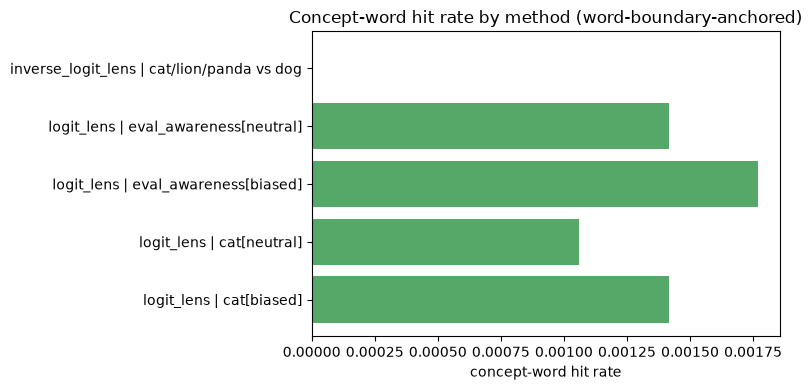

In [10]:
summary_rows = []
for name, (df, flat) in logit_lens_tables.items():
    rate, hits, total = concept_hit_rate(flat)
    summary_rows.append({'method': 'logit_lens', 'source': name, 'hit_rate': rate, 'hits': hits, 'total': total})
all_jlens_tokens = [t for df in jlens_contrastive_tables.values() for t in df['token']]
rate, hits, total = concept_hit_rate(all_jlens_tokens)
summary_rows.append({'method': 'inverse_logit_lens', 'source': 'cat/lion/panda vs dog', 'hit_rate': rate, 'hits': hits, 'total': total})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(summary_df['method'] + ' | ' + summary_df['source'], summary_df['hit_rate'], color='#55A868')
ax.set_xlabel('concept-word hit rate')
ax.set_title('Concept-word hit rate by method (word-boundary-anchored)')
plt.tight_layout()
plt.show()
